In [13]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp

L = 100 #number of lattice points in each dimension
size = L*L #total number of lattice points
J = 1  #Coupling Coefficient
N = 100 #number of monte-carlo steps for data collection
Neq = 20 #number of MCS for equilibration
Nt = 20 #number of temperatures sampled
Temps = np.logspace(-2,3,Nt)

#Data Collection
M_t = np.zeros(N) #magnetization
E_t = np.zeros(N) #energy per spin/lattice point
s_T = []
M_T = np.zeros(Nt)
E_T = np.zeros(Nt)

#Iterate over Temps
Tcounter = 0
for T in Temps:
    #Begin in Random Initial State
    state = np.random.choice([-1,1],(L,L))
    state_i = state.copy()
    #Begin Iteration of MCS (monte-carlo steps)
    for n_out in range(N+Neq):
        if n_out >= Neq:
            #compute and store magnetization
            M_t[n_out-Neq] = np.sum(state)/size
            #compute and store energy per spin
            E_t[n_out-Neq] = -J*np.sum(state*(np.roll(state,1,0)+np.roll(state,1,1)))/size
        #For each MCS, attempt flipping one spin for every lattice point
        for n_in in range(size):
            #choose a random lattice point
            xpos = np.random.randint(0,L)
            xp = xpos+1
            if xp == L:
                xp = 0
            xm = xpos-1
            ypos = np.random.randint(0,L)
            yp = ypos+1
            if yp == L:
                yp = 0
            ym = ypos-1
            #calculate change in energy of prospective flip
            dU = 2*J*state[xpos,ypos]*(state[xp,ypos] + state[xm,ypos] + state[xpos,yp] + state[xpos,ym])
            #decide whether to flip
            if dU <= 0:
                state[xpos,ypos] *= -1
            elif np.random.rand() < np.exp(-dU/T):
                state[xpos,ypos] *= -1
    M_T[Tcounter] = np.sum(M_t)/N
    E_T[Tcounter] = np.sum(E_t)/N
    state_f = state.copy()
    s_T.append((state_i,state_f))
    Tcounter += 1

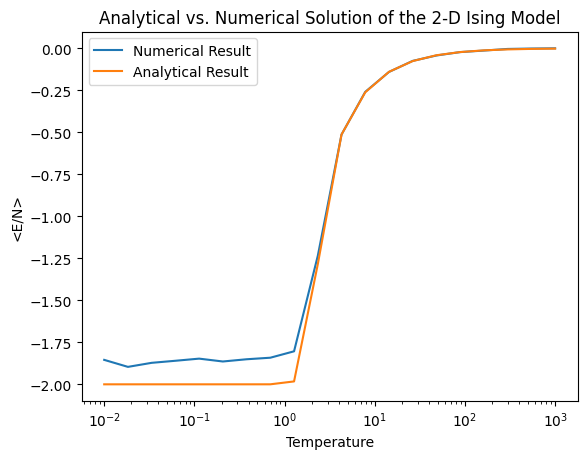

In [17]:
#Analytical Solution:
def analyticalE(T):
    k = (2*np.sinh(2*J/T))/(np.cosh(2*J/T))**2
    K = sp.ellipk(k**2)
    return (-J/np.tanh(2*J/T))*(1+(2/np.pi)*(-1+2*(np.tanh(2*J/T))**2)*K)
exactE_T = np.array([analyticalE(T) for T in Temps])
#Plot <E/N>(T)
plt.plot(Temps,E_T, label='Numerical Result')
plt.plot(Temps, exactE_T, label='Analytical Result')
plt.title("Analytical vs. Numerical Solution of the 2-D Ising Model")
plt.xscale('log')
plt.xlabel("Temperature")
plt.ylabel("<E/N>")
plt.legend()
plt.show()

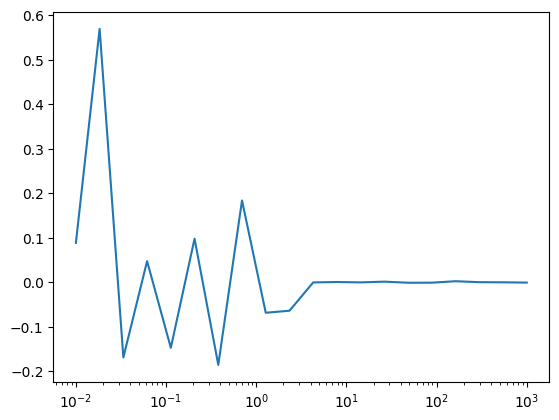

In [15]:
#Plot <M>(T)
plt.plot(Temps,M_T)
plt.xscale('log')
plt.show()

Temperature: 0.01


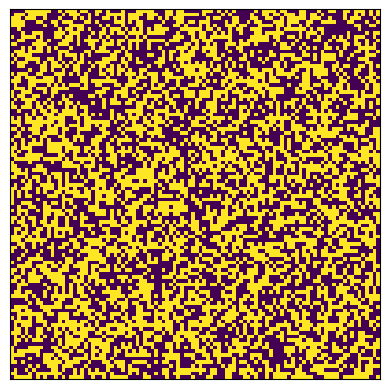

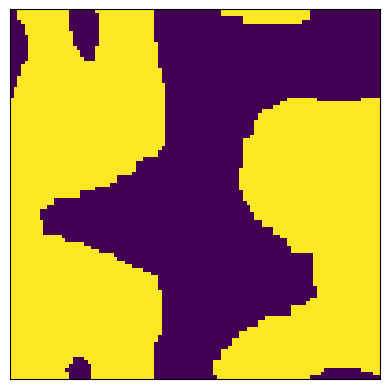

Temperature: 0.018329807108324356


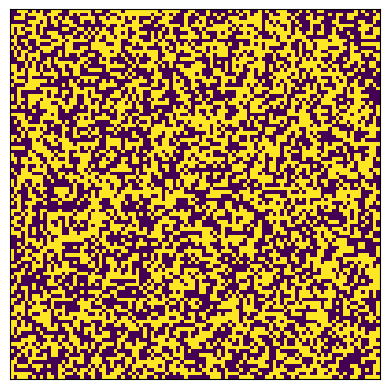

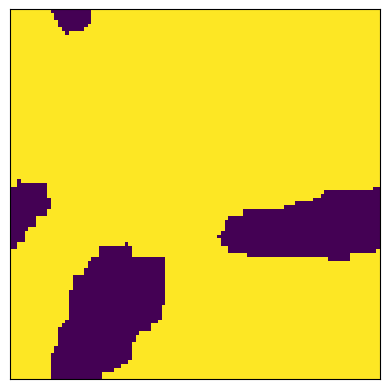

Temperature: 0.03359818286283781


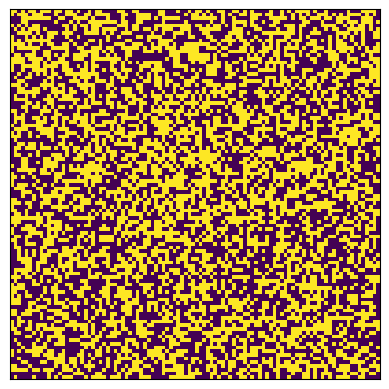

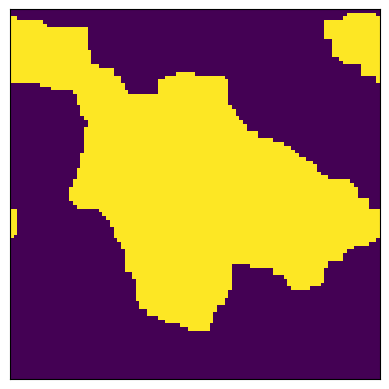

Temperature: 0.06158482110660264


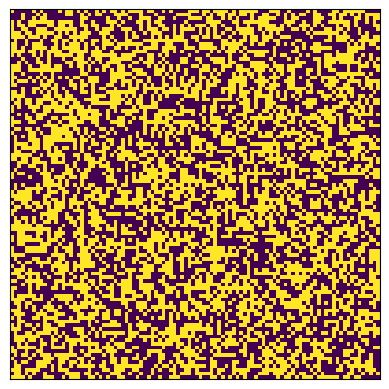

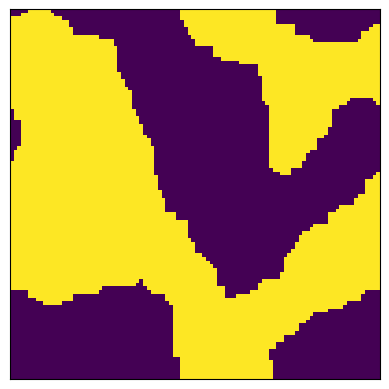

Temperature: 0.11288378916846889


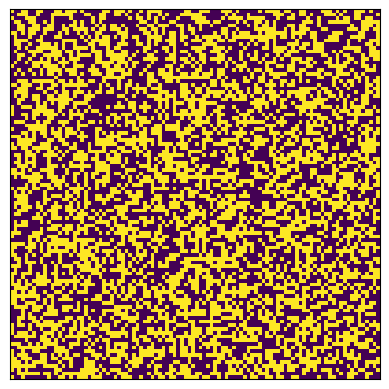

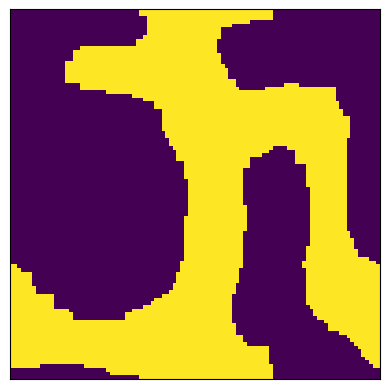

Temperature: 0.20691380811147891


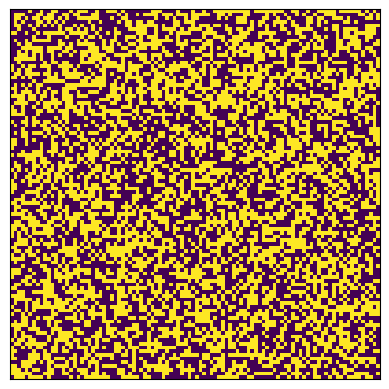

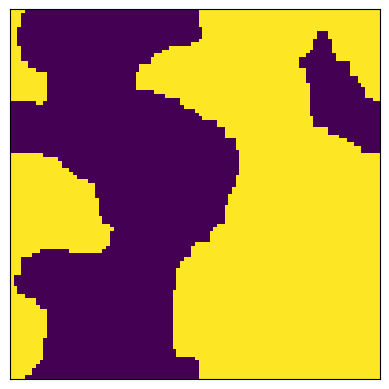

Temperature: 0.37926901907322497


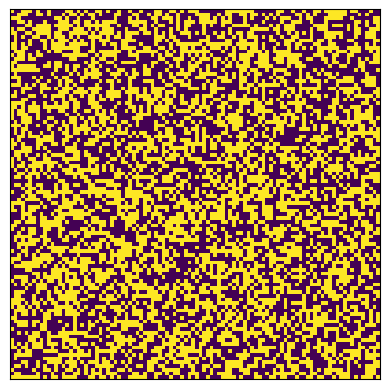

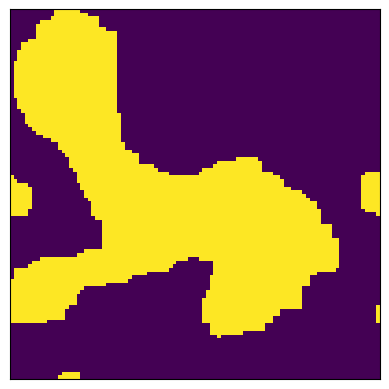

Temperature: 0.6951927961775606


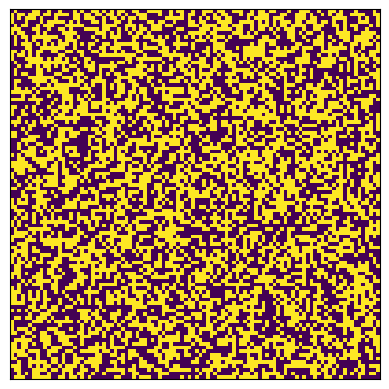

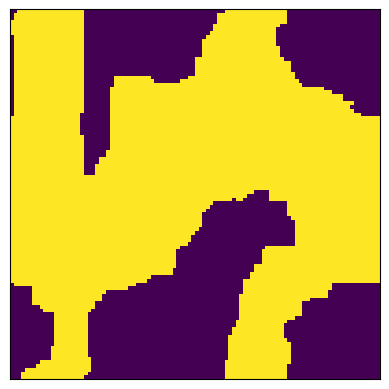

Temperature: 1.2742749857031335


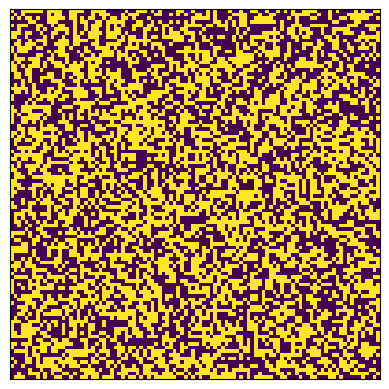

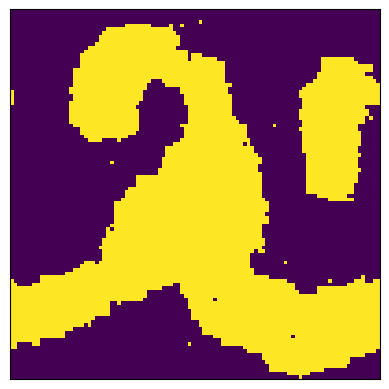

Temperature: 2.3357214690901213


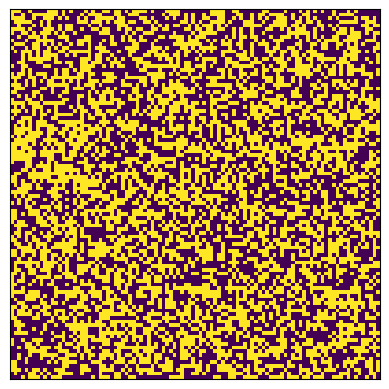

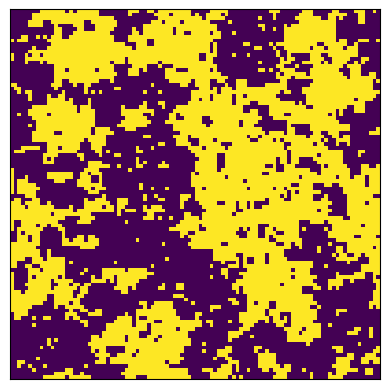

Temperature: 4.281332398719392


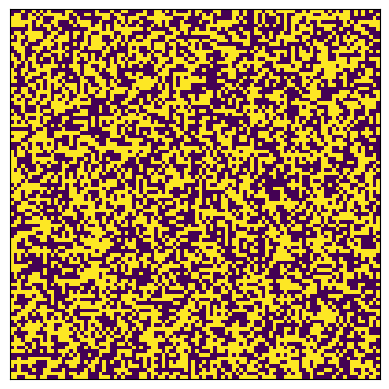

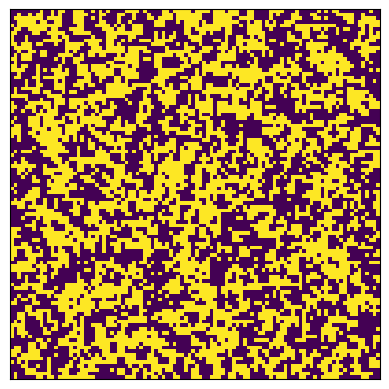

Temperature: 7.847599703514606


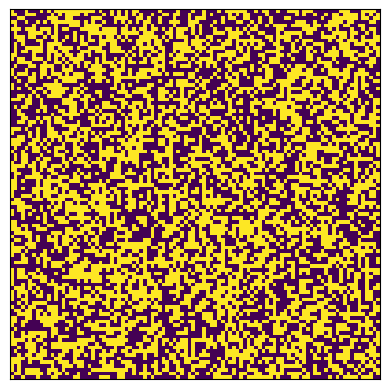

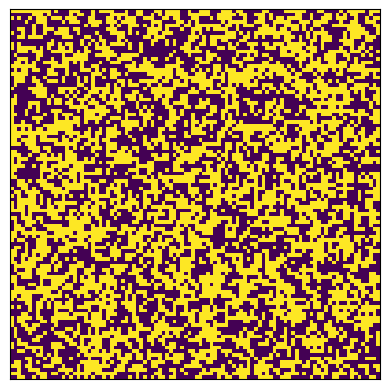

Temperature: 14.38449888287663


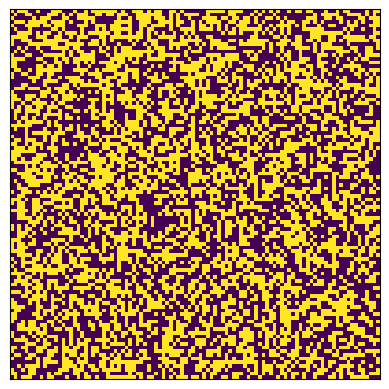

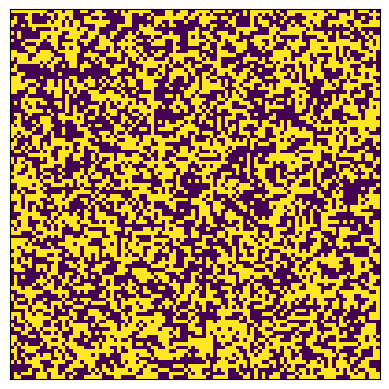

Temperature: 26.366508987303583


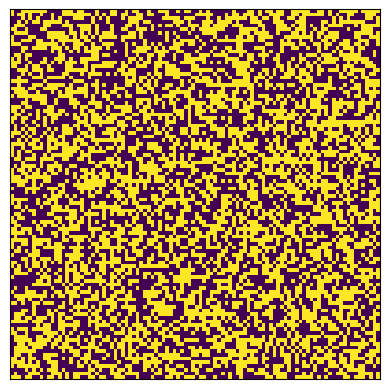

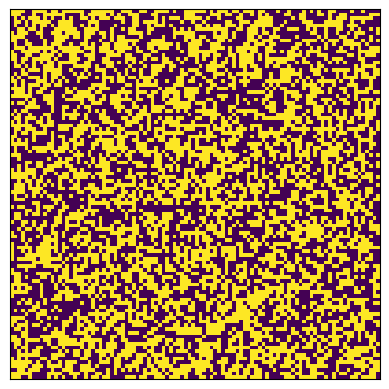

Temperature: 48.32930238571752


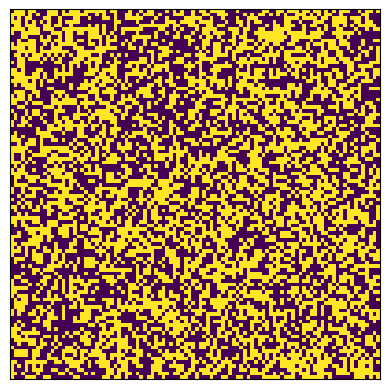

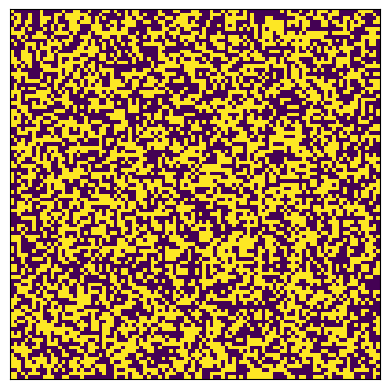

Temperature: 88.58667904100822


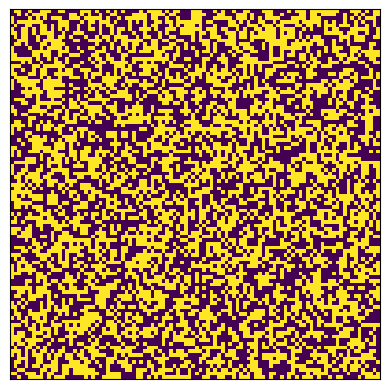

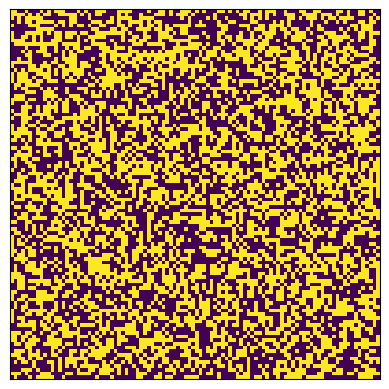

Temperature: 162.3776739188721


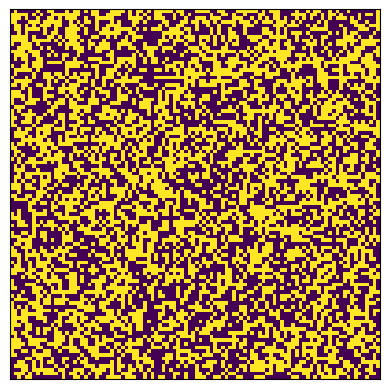

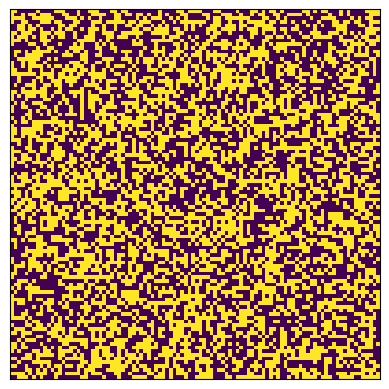

Temperature: 297.63514416313194


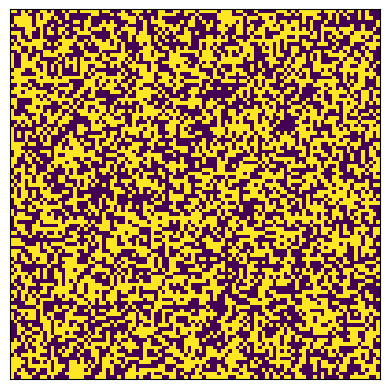

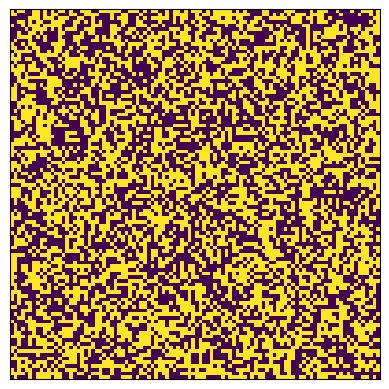

Temperature: 545.5594781168514


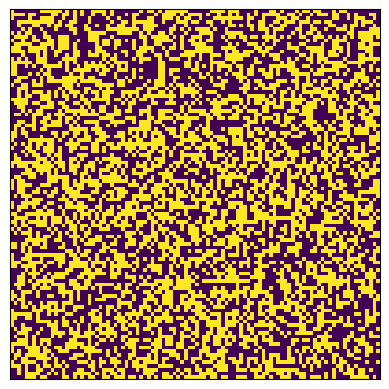

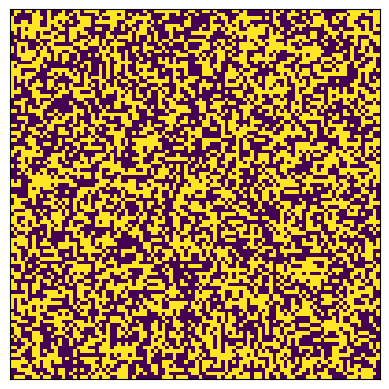

Temperature: 1000.0


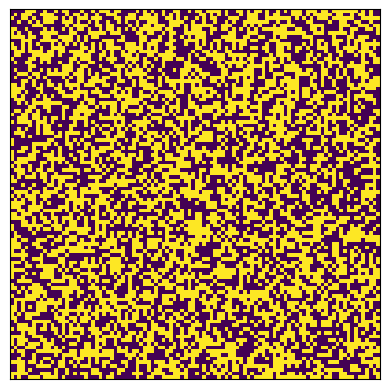

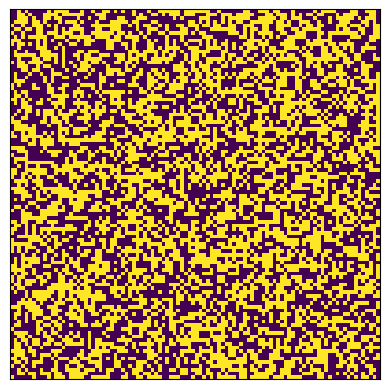

In [16]:
#Plot Spin Configurations
for i_T in range(Nt):
    print(f'Temperature: {Temps[i_T]}')
    plt.imshow(s_T[i_T][0])
    plt.xticks([]);
    plt.yticks([]);
    plt.show()
    plt.imshow(s_T[i_T][1])
    plt.xticks([]);
    plt.yticks([]);
    plt.show()